Data can be downloaded from 
https://drive.google.com/drive/folders/1SlWLf25CquN7reISjt021CplwCa2ScAG?usp=drive_link

Place downloaded data folder SCC under ./tutorial/

Figure 3 复现

# 0.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import sys
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [2]:
import sys
sys.path.insert(0, '/home/xtsong/Algos/StrInt')

In [3]:
from pyStrint import plotting as pl
from pyStrint import preprocess as pp
from pyStrint import evaluation as eva
from pyStrint import utils
# reload pp
import importlib
importlib.reload(pp)
# import sys
# sys.path.insert(0, '/data6/5.Simpute/StrInt-main/')
# from Strint import plotting as pl
# from Strint import preprocess as pp
# from Strint import evaluation as eva

<module 'pyStrint.preprocess' from '/home/xtsong/Algos/StrInt/pyStrint/preprocess.py'>

In [4]:

# --- injected compatibility/setup cell ---
import os
import pandas as pd
import numpy as np

BASE = '/bigdata/disk2/xtsong-data/strint/SCC_results'
ANA = f'{BASE}/ana'
os.makedirs(f'{ANA}/figures', exist_ok=True)
os.makedirs(f'{ANA}/saved', exist_ok=True)

spex_inputDir = BASE
Raw_inputDir = f'{BASE}/inputs'
outDir = f'{BASE}/ana/saved'

def _read_auto(fp):
    if fp.endswith('.tsv'):
        return pd.read_csv(fp, sep='	')
    return pd.read_csv(fp)

def load_alphatalk_major(adata, lr_fp, cci_dir):
    df = _read_auto(lr_fp).copy()
    # Prefer major-map columns when available (14 major cell types)
    if 'sender_major' in df.columns:
        df['celltype_sender'] = df['sender_major']
    elif 'cell_sender' in df.columns:
        df['celltype_sender'] = df['cell_sender']

    if 'receiver_major' in df.columns:
        df['celltype_receiver'] = df['receiver_major']
    elif 'cell_receiver' in df.columns:
        df['celltype_receiver'] = df['cell_receiver']
    if 'co_exp_number' in df.columns and 'lr_co_exp_num' not in df.columns:
        df['lr_co_exp_num'] = df['co_exp_number']
    if 'LRI' not in df.columns and {'ligand','receptor'}.issubset(df.columns):
        df['LRI'] = df['ligand'].astype(str) + '|' + df['receptor'].astype(str)
    if 'cell_pair' not in df.columns and {'celltype_sender','celltype_receiver'}.issubset(df.columns):
        df['cell_pair'] = df['celltype_sender'].astype(str) + '->' + df['celltype_receiver'].astype(str)
    adata.uns['spatalk'] = df

    rec = pd.read_csv(f'{cci_dir}/rec_per_major.tsv', sep='	', index_col=0)
    send = pd.read_csv(f'{cci_dir}/send_per_major.tsv', sep='	', index_col=0)
    nn = pd.read_csv(f'{cci_dir}/celltype_nn_major.tsv', sep='	')
    adata.uns['rec_per'] = rec
    adata.uns['send_per'] = send
    adata.uns['celltype_nn'] = nn

    cp = df.copy()
    cp['sender_tp'] = cp['celltype_sender']
    cp['receiver_tp'] = cp['celltype_receiver']
    cp['Name'] = cp['sender_tp'].astype(str) + ' -- ' + cp['receiver_tp'].astype(str)
    adata.uns['cellpair'] = cp
    adata.uns['tp_key'] = 'celltype_major'



spex_inputDir = '/bigdata/disk2/xtsong-data/strint/SCC_results/refined'
Raw_inputDir = '/bigdata/disk2/xtsong-data/strint/SCC_results/inputs'
outDir = '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures'
import os
os.makedirs('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures', exist_ok=True)
os.makedirs('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved', exist_ok=True)


In [5]:
spex_inputDir = '/bigdata/disk2/xtsong-data/strint/SCC_results/refined'
Raw_inputDir = '/bigdata/disk2/xtsong-data/strint/SCC_results/inputs'
outDir = '/bigdata/disk2/xtsong-data/strint/SCC_results'

In [6]:
palette_dict = {'Original':'#ef8a62','Refined':'#67a9cf','ST':"#C798EE"}

major_color_map = {'Myeloid':'#EC7063',
 'Endo':'#22a8a1',
 'KC':'#28B463',
 'KC (Cyc)':'#63C1A3',
 'KC (Diff)':'#59BE86',
 'KC (Basal)':'#76D7C4',
 'FB':"#3A84E6",
 'LC':'#3498DB',
 'T cell':'#E88AC2',
 'Epithelial':'#9DB0D4',
 'TSK':'#E74C3C',
 'B cell':'#ffb200',
 'Melanocyte':'#85C1E9',
 'NK':'#C798EE'}

color_map = {'ASDC': '#E74C3C',
 'MDSC':'#F56867',
 'B_Cell': '#D35400',
'B Cell': '#D35400',
 'CD1C': '#EC7063',
 'CD4_Naive': '#DC7633',
 'CD4_Pre_Exh': '#D95F02',
 'CD8_EM': '#ffb200',
 'CD8_Exh': '#ed5eb3',
 'CLEC9A': '#F5B7B1',
 'Eccrine': '#1B9E77',
 'Endothelial_Cell': '#28B463',
  'Endothelial Cell': '#28B463',
 'Fibroblast': '#85C1E9',
 'Keratinocyte': '#58D68D',
 'LC': '#22a8a1',
 'Mac': '#EC7063',
 'Melanocyte': '#2B83BA',
 'Mig_CD1C': '#007FFF',
 'Mig_CLEC9A': '#3498DB',
 'Mig_LC': '#00c9ff',
 'NK': '#8cc63f',
 'PDC': '#9DB0D4',
 'Pilosebaceous': '#5E3C99',
 'TSK': '#EC7063',
 'Treg': '#22a8a1',
 'Tumor_KC_Basal': '#AF7AC5',
 'Tumor_KC_Cyc': '#D2B4DE',
 'Tumor_KC_Diff': '#E88AC2'}

minor_map = {'CLEC9A': 'Myeloid',
 'Endothelial_Cell': 'Endo',
 'Endothelial Cell': 'Endo',
 'CD1C': 'Myeloid',
 'Keratinocyte': 'KC',
 'Tumor_KC_Cyc': 'KC (Cyc)',
 'Fibroblast': 'FB',
 'LC': 'LC',
 'Mig_CD1C': 'Myeloid',
 'Mac': 'Myeloid',
 'Tumor_KC_Basal': 'KC (Basal)',
 'ASDC': 'Myeloid',
 'CD8_Exh': 'T cell',
 'Pilosebaceous': 'Epithelial',
 'Tumor_KC_Diff': 'KC (Diff)',
 'PDC': 'Myeloid',
 'Mig_LC': 'LC',
 'Treg': 'T cell',
 'TSK': 'TSK',
 'MDSC': 'Myeloid',
 'Eccrine': 'Epithelial',
 'B_Cell': 'B cell',
  'B Cell': 'B cell',
 'Melanocyte': 'Melanocyte',
 'CD8_EM': 'T cell',
 'CD4_Naive': 'T cell',
 'CD4_Pre_Exh': 'T cell',
 'Mig_CLEC9A': 'Myeloid',
 'NK': 'NK'}

In [7]:
species = 'Human'
new_exp_fn = f'{spex_inputDir}/refined_sc_exp.tsv'
new_meta_fn = f'{spex_inputDir}/cell_mapping_meta.tsv'

alter_exp = pd.read_csv(new_exp_fn,sep='\t',index_col=0,header=0)
sc_agg_meta = pd.read_csv(new_meta_fn,sep='\t',index_col=0,header=0)
sc_agg_meta['adj_spex_UMAP2'] = sc_agg_meta['adj_spex_UMAP2']*-1
sc_agg_meta['st_y'] = sc_agg_meta['st_y']*-1

In [8]:
refine_adata = pp.make_adata(alter_exp,sc_agg_meta,species,save_path = outDir, save_adata = False)
refine_adata.obs['celltype_major'] = refine_adata.obs['celltype'].map(minor_map)
refine_adata._uns['tp_key'] = 'celltype_major'
refine_adata._uns['major_color_map'] = major_color_map

AnnData object created:
  - Cells: 7144
  - Genes: 10659
  - Species: Human


In [9]:
# set Rscript path
rscript_path = utils.find_executable_in_path('Rscript')
refine_adata.uns['rscript_path'] = rscript_path if rscript_path else 'Not found Rscript'
# set Python path
python_path = sys.executable
refine_adata.uns['python_path'] = python_path

print(f"Rscript: {refine_adata.uns['rscript_path']}")
print(f"Python: {refine_adata.uns['python_path']}")

Rscript: /home/xtsong/miniforge3/envs/strint_3/bin/Rscript
Python: /home/xtsong/miniforge3/envs/strint_3/bin/python


In [10]:
refine_adata

AnnData object with n_obs × n_vars = 7144 × 10659
    obs: 'sc_id', 'spot', 'exp_cor_before', 'interface_cor_before', 'mix_cor_before', 'exp_cor_after', 'interface_cor_after', 'mix_cor_after', 'celltype', 'UMAP1', 'UMAP2', 'st_x', 'st_y', 'spex_UMAP1', 'spex_UMAP2', 'indice', 'core1', 'core2', 'centering_scale_factor', 'adj_spex_UMAP1', 'adj_spex_UMAP2', 'celltype_major'
    var: 'symbol', 'MT_gene'
    uns: 'species', 'save_path', 'figpath', 'tp_key', 'major_color_map', 'rscript_path', 'python_path'

In [11]:
refine_adata.uns['save_path'] = '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved'
refine_adata.uns['figpath'] = '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures/'


In [12]:
# before adata
species = 'Human'
before_exp_fn = '/bigdata/disk2/xtsong-data/strint/SCC_results/original/before_sc_exp.tsv'
before_meta_fn = '/bigdata/disk2/xtsong-data/strint/SCC_results/original/sc_agg_meta.tsv'

before_exp = pd.read_csv(before_exp_fn,sep='	',index_col=0,header=0)
before_meta = pd.read_csv(before_meta_fn,sep='	',index_col=0,header=0)
if 'adj_spex_UMAP2' in before_meta.columns:
    before_meta['adj_spex_UMAP2'] = before_meta['adj_spex_UMAP2']*-1
if 'st_y' in before_meta.columns:
    before_meta['st_y'] = before_meta['st_y']*-1


In [13]:
# before adata
before_adata = pp.make_adata(before_exp,before_meta,species,save_path = '/bigdata/disk2/xtsong-data/strint/SCC_results/before', save_adata = False)
before_adata.obs['celltype_major'] = before_adata.obs['celltype'].map(minor_map)
before_adata._uns['tp_key'] = 'celltype_major'
before_adata._uns['major_color_map'] = major_color_map

AnnData object created:
  - Cells: 7244
  - Genes: 10654
  - Species: Human


In [14]:
# set Rscript path of before
rscript_path = utils.find_executable_in_path('Rscript')
before_adata.uns['rscript_path'] = rscript_path if rscript_path else 'Not found Rscript'
# set Python path
python_path = sys.executable
before_adata.uns['python_path'] = python_path

print(f"Rscript: {before_adata.uns['rscript_path']}")
print(f"Python: {before_adata.uns['python_path']}")

Rscript: /home/xtsong/miniforge3/envs/strint_3/bin/Rscript
Python: /home/xtsong/miniforge3/envs/strint_3/bin/python


# 1. Overview

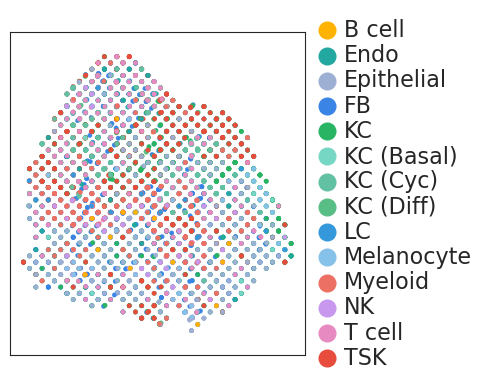

<Figure size 640x480 with 0 Axes>

In [15]:
pl.sc_celltype(refine_adata, color_map = major_color_map,tp_key = 'celltype_major', figsize= (3.8,4.2),
        legend = True, size = 10, alpha = 1, savefig = True)

In [16]:
# pl.sc_subtype(refine_adata,color_map = major_color_map,tp_key = 'celltype_major', savefig = True)

In [17]:
# pl.sc_subtype(refine_adata,color_map = major_color_map,tp_key = 'celltype_major',target_tp = ['TSK','FB'], savefig = True)

# 2. Spot Correlation

! pip install configargparse

In [18]:
before_spot_cor = eva.runSpotCor(before_adata, recon_exp_file = '',
                                 recon_meta_file = before_meta_fn,
               orig_sc_file = f'{Raw_inputDir}/SC_exp.tsv', orig_st_file = f'{Raw_inputDir}/ST_exp.tsv')

No exp file, Pull cells from original sc_exp


In [19]:
before_spot_cor.mean()

cor    0.734335
dtype: float64

In [20]:
refine_spot_cor = eva.runSpotCor(refine_adata, recon_exp_file = new_exp_fn,
                                 recon_meta_file = new_meta_fn,
               orig_sc_file = f'{Raw_inputDir}/SC_exp.tsv', orig_st_file = f'{Raw_inputDir}/ST_exp.tsv')


In [21]:
refine_spot_cor.mean()

cor    0.918566
dtype: float64

In [23]:
before_spot_cor['Method'] = 'Original'
refine_spot_cor['Method'] = 'Refined'
spot_cor = pd.concat([before_spot_cor,refine_spot_cor])

In [22]:
# import os
# os.makedirs('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved/spot_cor',exist_ok=True)
# spot_cor.to_csv('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved/spot_cor/spot_cor.tsv',sep='\t',index=False)


<Axes: ylabel='Spot correlation'>

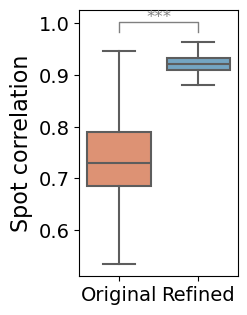

In [24]:
pl.boxplot(spot_cor,palette_dict = palette_dict,
                x='Method', y='cor',  ylabel='Spot correlation', 
                test = 't-test_ind',figsize=(2.4,3.4),savefig =refine_adata.uns['figpath'] + '/spot_cor.pdf')

# 3. AlphaTalk

## refine_adata

In [15]:
refine_adata

AnnData object with n_obs × n_vars = 7144 × 10659
    obs: 'sc_id', 'spot', 'exp_cor_before', 'interface_cor_before', 'mix_cor_before', 'exp_cor_after', 'interface_cor_after', 'mix_cor_after', 'celltype', 'UMAP1', 'UMAP2', 'st_x', 'st_y', 'spex_UMAP1', 'spex_UMAP2', 'indice', 'core1', 'core2', 'centering_scale_factor', 'adj_spex_UMAP1', 'adj_spex_UMAP2', 'celltype_major'
    var: 'symbol', 'MT_gene'
    uns: 'species', 'save_path', 'figpath', 'tp_key', 'major_color_map', 'rscript_path', 'python_path'

In [15]:
# Use AlphaTalk MAJOR-MAP results to generate CCI directly (14 major cell types).
alphatalk_refined_fp = '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/alphatalk/major_map/tables/refined_lr_st_filter_major.csv'

In [16]:
draw_rec,draw_send = eva.generate_cci_alphatalk(
    refine_adata,
    alphatalk_path=alphatalk_refined_fp,
    sender_col='sender_major',
    receiver_col='receiver_major',
    return_df=True
)
load_alphatalk_major(
    refine_adata,
    '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/alphatalk/major_map/tables/refined_lr_st_filter_major.csv',
    '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/alphatalk/cci/refine'
)
# keep draw_send consistent with major-map CCI used by plotting
draw_send = refine_adata.uns['send_per'].copy()
draw_rec = refine_adata.uns['rec_per'].copy()
refine_adata.uns['spatalk_meta']=pd.DataFrame({'cell':refine_adata.obs.index.astype(str)},index=refine_adata.obs.index.astype(str))


In [17]:
draw_send

,B cell,Endo,Epithelial,FB,KC,KC (Basal),KC (Cyc),KC (Diff),LC,Melanocyte,Myeloid,NK,T cell,TSK
sender_tp,,,,,,,,,,,,,,
B cell,0.000000,0.095238,0.190476,0.666667,0.047619,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Endo,0.001200,0.000000,0.174565,0.110078,0.000000,0.121476,0.124475,0.000000,0.000000,0.011998,0.127774,0.012897,0.188962,0.126575
Epithelial,0.004819,0.190361,0.316466,0.139759,0.042972,0.046185,0.066667,0.000000,0.000000,0.029719,0.101205,0.008835,0.053012,0.000000
FB,0.032320,0.000000,0.121247,0.057755,0.055842,0.079174,0.090266,0.000000,0.000191,0.047237,0.131956,0.043794,0.258176,0.082042
KC,0.000000,0.000000,0.119797,0.162437,0.150254,0.000000,0.269036,0.076142,0.000000,0.084264,0.006091,0.000000,0.037563,0.094416
KC (Basal),0.000000,0.130758,0.086924,0.110327,0.097697,0.089153,0.113670,0.069837,0.002229,0.030089,0.090267,0.000000,0.072808,0.106241
KC (Cyc),0.000000,0.179070,0.000000,0.180814,0.000000,0.135465,0.152326,0.111047,0.000000,0.000000,0.000000,0.000000,0.080233,0.161047
KC (Diff),0.000000,0.000000,0.104079,0.000000,0.199719,0.000000,0.400844,0.120956,0.000000,0.000000,0.026723,0.000000,0.000000,0.147679
LC,0.000000,0.000000,0.000000,0.220930,0.430233,0.093023,0.011628,0.000000,0.000000,0.000000,0.244186,0.000000,0.000000,0.000000


In [18]:
sender_order = ['B cell','Myeloid','Melanocyte','NK',
                'TSK','T cell','KC', 'KC (Basal)', 'KC (Cyc)', 'KC (Diff)',
                'FB', 'Endo', 'Epithelial','LC']

4 6


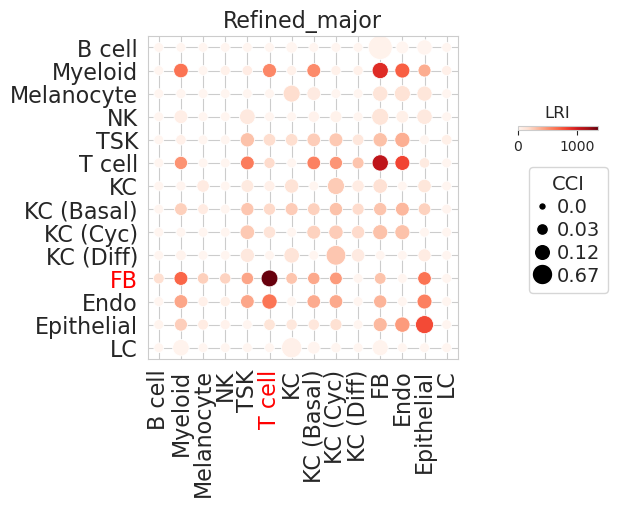

<Figure size 640x480 with 0 Axes>

In [41]:
import os, shutil
os.makedirs('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures', exist_ok=True)
pl.celltype_cci(refine_adata, is_sender_per=True, figsize=(4,6),
            target_sender=sender_order, target_receiver=sender_order,
            y_highlight=['FB'], x_highlight=['T cell'],
            cmap='Reds', size='CCI', hue='LRI',
            savefig=True, color_bar_pos=[1.05, 0.38, 0.2, 0.35], title='Refined_major')
src='/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures/sender_CCI.pdf'
dst='/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures/sender_CCI_refined_major.pdf'
if os.path.exists(src):
    shutil.copyfile(src,dst)
draw_send.to_csv('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved/refined/spa/CCI/draw_send_refined_major.csv')


## before

In [17]:
before_adata.uns['save_path'] = '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved/before'
before_adata.uns['figpath'] = '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures/'

In [18]:
# Use AlphaTalk MAJOR-MAP results to generate CCI directly (14 major cell types).
alphatalk_original_fp = '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/alphatalk/major_map/tables/original_lr_st_filter_major.csv'


In [19]:
draw_rec,draw_send = eva.generate_cci_alphatalk(
    before_adata,
    alphatalk_path=alphatalk_original_fp,
    sender_col='sender_major',
    receiver_col='receiver_major',
    return_df=True
)
load_alphatalk_major(
    before_adata,
    '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/alphatalk/major_map/tables/original_lr_st_filter_major.csv',
    '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/alphatalk/cci/original'
)
draw_send = before_adata.uns['send_per'].copy()
draw_rec = before_adata.uns['rec_per'].copy()


In [22]:
sender_order = ['B cell','Myeloid','Melanocyte','NK',
                'TSK','T cell','KC', 'KC (Basal)', 'KC (Cyc)', 'KC (Diff)',
                'FB', 'Endo', 'Epithelial','LC']

4 6


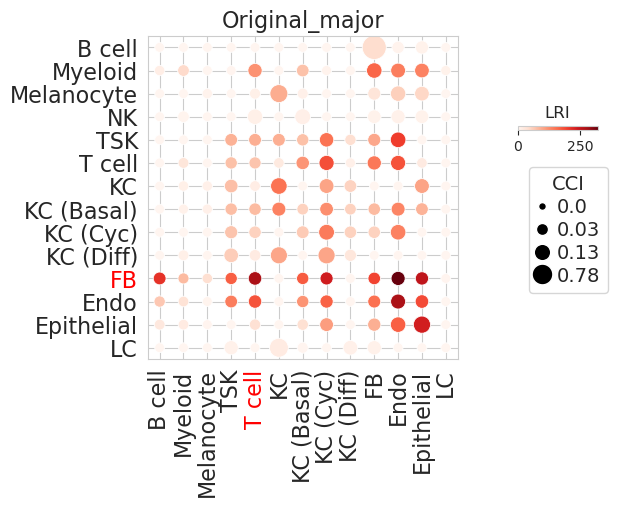

<Figure size 640x480 with 0 Axes>

In [46]:
import os, shutil
os.makedirs('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures', exist_ok=True)
pl.celltype_cci(before_adata, is_sender_per=True, figsize=(4,6),
            target_sender=sender_order, target_receiver=sender_order,
            y_highlight=['FB'], x_highlight=['T cell'],
            cmap='Reds', size='CCI', hue='LRI',
            savefig=True, color_bar_pos=[1.05, 0.38, 0.2, 0.35], title='Original_major')
src='/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures/sender_CCI.pdf'
dst='/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures/sender_CCI_original_major.pdf'
if os.path.exists(src):
    shutil.copyfile(src,dst)
draw_send.to_csv('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved/before/spa/CCI/draw_send_before_major.csv')


In [53]:
# import os
# os.makedirs('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved/before/spa/CCI',exist_ok=True)
# draw_send.to_csv('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved/before/spa/CCI/draw_send_before_major.csv')
# os.makedirs('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved/refined/spa/CCI',exist_ok=True)
# refine_adata.uns['send_per'].to_csv('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved/refined/spa/CCI/draw_send_refined_major.csv')


In [52]:
# # Compare Original vs Refined with shared color scale (major-cell CCI sender proportion)
# import os
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# os.makedirs('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures', exist_ok=True)

# major_order = ['B cell','Myeloid','Melanocyte','NK','TSK','KC','KC (Basal)','KC (Cyc)','KC (Diff)','FB','Endo','Epithelial','LC','T cell']
# orig = before_adata.uns['send_per'].copy()
# refi = refine_adata.uns['send_per'].copy()
# orig = orig.reindex(index=major_order, columns=major_order).fillna(0)
# refi = refi.reindex(index=major_order, columns=major_order).fillna(0)
# vmin = 0
# vmax = max(float(orig.to_numpy().max()), float(refi.to_numpy().max()))

# fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
# hm0 = sns.heatmap(orig, ax=axes[0], cmap='Reds', vmin=vmin, vmax=vmax, cbar=False, square=True)
# axes[0].set_title('Original (shared scale)', fontsize=12)
# axes[0].set_xlabel('Receiver major cell type')
# axes[0].set_ylabel('Sender major cell type')

# hm1 = sns.heatmap(refi, ax=axes[1], cmap='Reds', vmin=vmin, vmax=vmax, cbar=False, square=True)
# axes[1].set_title('Refined (shared scale)', fontsize=12)
# axes[1].set_xlabel('Receiver major cell type')
# axes[1].set_ylabel('')

# for ax in axes:
#     ax.tick_params(axis='x', labelrotation=60, labelsize=8)
#     ax.tick_params(axis='y', labelsize=8)

# # cbar = fig.colorbar(hm1.collections[0], ax=axes, fraction=0.025, pad=0.02)


# # 手动放置 colorbar（[left, bottom, width, height]，图坐标）
# fig.subplots_adjust(right=0.88)              # 给右侧腾位置
# cax = fig.add_axes([1.0, 0.18, 0.02, 0.64]) # 往右放
# cbar = fig.colorbar(hm1.collections[0], cax=cax)

# cbar.set_label('Sender proportion', fontsize=10)

# plt.tight_layout()
# out_fp='/bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures/sender_CCI_original_vs_refined_shared_scale_major.pdf'
# plt.savefig(out_fp, bbox_inches='tight')
# plt.show()
# print('saved:', out_fp)


# 4. CCI

## 4.1 LRI overview of target cell types

In [20]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
colors = {'red': '#9DC5D8', 'white': '#F5DAC9', 'blue': '#DF7D97'}
# Create a list of tuples specifying the color map
colors_map = [(0.0, colors['red']), (0.5, colors['white']), (1.0, colors['blue'])]
# Create the colormap using LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list('my_colormap', colors_map)

### refine data

In [21]:
spa_res = refine_adata.uns['spatalk']
# t_mye_spa = spa_res[(spa_res['celltype_sender'] == 'T cell') & (spa_res['celltype_receiver'] == 'Myeloid')]
fb_t_plot = spa_res[(spa_res['celltype_sender'] == 'FB') & (spa_res['celltype_receiver'] == 'T cell')]

In [22]:
# t_fb_spa = spa_res[(spa_res['celltype_sender'] == 'FB') & (spa_res['celltype_receiver'] == 'T cell')]

In [23]:
# t_fb_spa.to_csv('/bigdata/disk2/xtsong-data/strint/SCC_results/spa/t_fb_spa.tsv')

In [24]:
if len(fb_t_plot)>0:
    top_lig = fb_t_plot['ligand'].value_counts().head(20).index
    top_rec = fb_t_plot['receptor'].value_counts().head(20).index
    fb_t_plot = fb_t_plot[(fb_t_plot['ligand'].isin(top_lig)) & (fb_t_plot['receptor'].isin(top_rec))].copy()
else:
    top_lig=[]
    top_rec=[]
    fb_t_plot=fb_t_plot.copy()


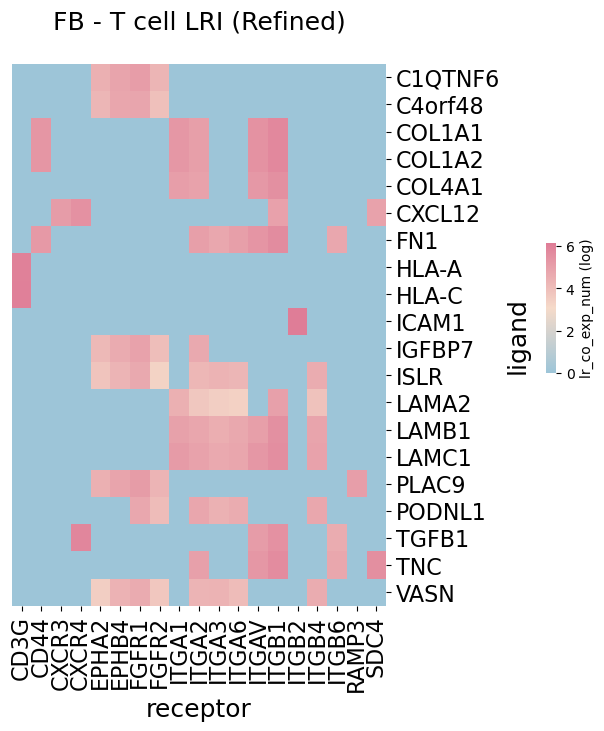

In [25]:
if len(fb_t_plot)>0:
    pl.clustermap(fb_t_plot, index='ligand', col='receptor', value='lr_co_exp_num', aggfunc='sum', log=True, scale=False, row_cluster=False, col_cluster=False, cmap=cmap, title='FB - T cell LRI (Refined)', rotate_x=True, xticks=True, yticks=True, xlabel=True, ylabel=True, cbar_x=1.1, figsize=(5,6.5), col_colors=None, row_colors=None, savefig=refine_adata.uns['figpath'] + 't_fb_alpha_heatmap_refined_1.pdf')

### original

In [26]:
def clustermap(df, index = 'ligand', col = 'receptor', value = 'lr_co_exp_num',
                 aggfunc = 'sum', log = True, scale = False, row_cluster = False, col_cluster = False,
                 highlight = None,  cmap = 'coolwarm', title = '', rotate_x = True,
                 xticks = False, yticks = True, xlabel = True, ylabel = True, cbar_x = 1.2,
                 figsize = (5,5),col_colors = None, row_colors = None,
                 savefig = False):
    '''
    df: dataframe
    if df has there columns and required to be pivot, then use the following parameters
    otherwise set aggfunc as None
        index: row index
        col: column index
        value: value to fill the pivot table
        aggfunc: how to aggregate the value
    log: log the value or not
    row_cluster: cluster row or not
    col_cluster: cluster column or not
    highlight: highlight the rows
    title: title of the plot
    cmap: color map of heatmap
    col_color: color of the column [sorted by the df row's order]
    xticks: show xticks or not
    yticks: show yticks or not
    savefig: output directory
    '''
    if aggfunc is None:
        n_tp_lri = df.copy()
    else:
        if aggfunc == 'sum':
            n_tp_lri = pd.crosstab(index=df[index], columns = df[col],values=df[value],aggfunc = sum)
    n_tp_lri = n_tp_lri.fillna(0)
    if log:
        n_tp_lri = np.log(n_tp_lri + 1)
        legend_label = f'{value} (log)'
    else:
        legend_label = f'{value}'

    if scale == True:
        n_tp_lri = n_tp_lri.apply(lambda x: (x - np.min(x)) / (np.max(x) - np.min(x)))
        
    clustermap = sns.clustermap(n_tp_lri,row_cluster=row_cluster,col_cluster=col_cluster,
               standard_scale=None,dendrogram_ratio=0.001,cmap = cmap, col_colors = col_colors,row_colors = row_colors,
               figsize=figsize, cbar_pos=(cbar_x, 0.5, 0.02, 0.2),cbar_kws={'orientation': 'vertical','label':legend_label})
    if not xticks:
        clustermap.ax_heatmap.set_xticklabels([])
        clustermap.ax_heatmap.set_xticks([])
    else:
        clustermap.ax_heatmap.xaxis.label.set_size(18)

        clustermap.ax_heatmap.set_xticklabels(
            clustermap.ax_heatmap.get_xticklabels(),
            rotation=90 if rotate_x else 0,
            fontsize=16
        )

    
    if not yticks:
        clustermap.ax_heatmap.set_yticklabels([])
        clustermap.ax_heatmap.set_yticks([])
    else:
        clustermap.ax_heatmap.yaxis.label.set_size(18)
        clustermap.ax_heatmap.set_yticklabels(
            clustermap.ax_heatmap.get_yticklabels(),
            rotation=90 if rotate_x else 0,
            fontsize=16
        )

    if not xlabel:
        clustermap.ax_heatmap.set_xlabel('')
    else:
        if xlabel != True:
            clustermap.ax_heatmap.set_xlabel(xlabel)
    if not ylabel:
        clustermap.ax_heatmap.set_ylabel('')
    else:
        if ylabel != True:
            clustermap.ax_heatmap.set_ylabel(ylabel)

    if highlight is not None:
        arr = n_tp_lri.index.to_list()
        if row_cluster:
            # Reorganize the index labels based on the cluster order
            reordered_index = [arr[i] for i in clustermap.dendrogram_row.reordered_ind]
            # Customize the ytick color and font weight
            yticks, _ = plt.yticks()
            ytick_labels = clustermap.ax_heatmap.get_yticklabels()
            for index, ytick_label in enumerate(ytick_labels):
                if reordered_index[index] in highlight:
                    ytick_label.set_color('red')
                    ytick_label.set_weight('bold')
        else:
            highlighted_ytick = np.where(np.isin(arr, highlight))[0]
            print(highlighted_ytick) # The ytick to be highlighted
            # Customize the ytick color
            _, yticks = plt.yticks()
            print(yticks)
            ytick_labels = clustermap.ax_heatmap.get_yticklabels()
            for index, ytick_label in enumerate(ytick_labels):
                if arr[index] in highlight:
                    ytick_label.set_color('red')
                    ytick_label.set_weight('bold')
    if title:
        clustermap.ax_heatmap.set_title(title,fontsize=18, y = 1.05) 

    if savefig:
        plt.savefig(f'{savefig}', bbox_inches='tight')

    # plt.xticks(fontsize=16)
    # plt.yticks(fontsize=16)

    # if rotate_x:
    #     # print('r')
    #     plt.xticks(fontsize=16, rotation=90)
    plt.show()

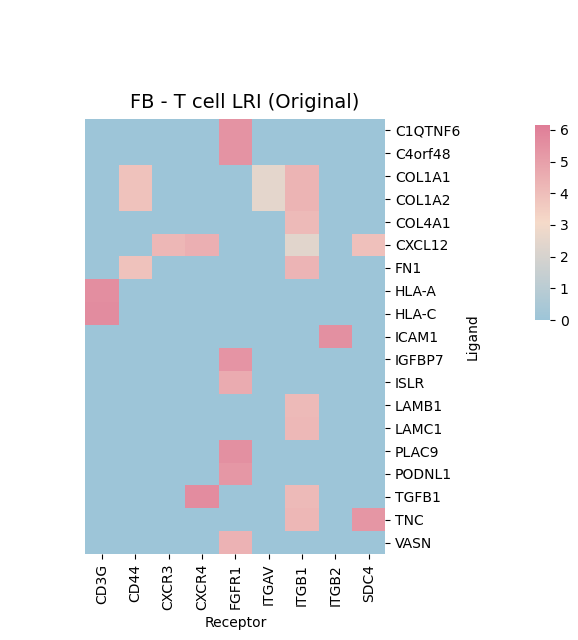

In [25]:
# before: use SAME LR set and SAME color scale as refined FB->T cell heatmap
spa_res_bef = before_adata.uns['spatalk']
fb_t_spa_bef = spa_res_bef[(spa_res_bef['celltype_sender'] == 'FB') & (spa_res_bef['celltype_receiver'] == 'T cell')].copy()
fb_t_spa_ref = refine_adata.uns['spatalk'][(refine_adata.uns['spatalk']['celltype_sender'] == 'FB') & (refine_adata.uns['spatalk']['celltype_receiver'] == 'T cell')].copy()

if 'lr_co_exp_num' not in fb_t_spa_bef.columns and 'co_exp_number' in fb_t_spa_bef.columns:
    fb_t_spa_bef['lr_co_exp_num'] = fb_t_spa_bef['co_exp_number']
if 'lr_co_exp_num' not in fb_t_spa_ref.columns and 'co_exp_number' in fb_t_spa_ref.columns:
    fb_t_spa_ref['lr_co_exp_num'] = fb_t_spa_ref['co_exp_number']

if 'top_lig' in globals() and 'top_rec' in globals() and len(top_lig)>0 and len(top_rec)>0:
    fb_t_plot_ref = fb_t_spa_ref[(fb_t_spa_ref['ligand'].isin(top_lig)) & (fb_t_spa_ref['receptor'].isin(top_rec))].copy()
    fb_t_plot_bef = fb_t_spa_bef[(fb_t_spa_bef['ligand'].isin(top_lig)) & (fb_t_spa_bef['receptor'].isin(top_rec))].copy()
else:
    fb_t_plot_ref = fb_t_spa_ref.copy()
    fb_t_plot_bef = fb_t_spa_bef.copy()

import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
ref_mat = pd.crosstab(index=fb_t_plot_ref['ligand'], columns=fb_t_plot_ref['receptor'], values=fb_t_plot_ref['lr_co_exp_num'], aggfunc=sum).fillna(0)
ref_mat = np.log(ref_mat + 1)
vmin = float(ref_mat.values.min()) if ref_mat.size>0 else 0.0
vmax = float(ref_mat.values.max()) if ref_mat.size>0 else 1.0

if len(fb_t_plot_bef) > 0:
    bef_mat = pd.crosstab(index=fb_t_plot_bef['ligand'], columns=fb_t_plot_bef['receptor'], values=fb_t_plot_bef['lr_co_exp_num'], aggfunc=sum).fillna(0)
    bef_mat = np.log(bef_mat + 1)
    cg = sns.clustermap(bef_mat, cmap=cmap, vmin=vmin, vmax=vmax, row_cluster=False, col_cluster=False, figsize=(5,6.5), cbar_pos=(1.08,0.5,0.03,0.3))
    plt.suptitle('FB - T cell LRI (Original)', y=0.85, fontsize=14)
    cg.ax_heatmap.set_xlabel('Receptor')
    cg.ax_heatmap.set_ylabel('Ligand')
    plt.savefig(before_adata.uns['figpath'] + 't_fb_alpha_heatmap_original_sameLR.pdf', bbox_inches='tight')
    plt.show()
else:
    print('No FB->T cell interactions after applying refined top_lig/top_rec filter in original data.')


## 4.2 KEGG

对于上面的T- Myeloid细胞通讯，进行enrich

In [23]:
kegg_enrich = eva.runKEGG(refine_adata, rscript_executable=None, input_df=fb_t_plot, df_name='fb_t_cell')

/home/xtsong/miniforge3/envs/strint_3/lib/R/bin/R: line 8: uname: command not found
/home/xtsong/miniforge3/envs/strint_3/lib/R/etc/ldpaths: line 12: uname: command not found
Warning message:
package ‘clusterProfiler’ was built under R version 4.2.2 
Warning messages:
1: package ‘AnnotationDbi’ was built under R version 4.2.2 
2: package ‘BiocGenerics’ was built under R version 4.2.1 
3: package ‘Biobase’ was built under R version 4.2.3 
4: package ‘IRanges’ was built under R version 4.2.3 
5: package ‘S4Vectors’ was built under R version 4.2.3 


[1] "fb_t_cell_kegg.tsv"


'select()' returned 1:1 mapping between keys and columns


fb_t_cell


sh: rm: command not found


In [28]:
# skipped in automated rerun due unavailable external dependency or malformed exploratory snippet
kegg_enrich.to_csv('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved/kegg/fb_t_kegg_final.csv')

In [26]:
kegg_enrich = pd.read_csv('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/saved/kegg/fb_t_kegg_final.csv')

In [31]:
# skipped in automated rerun due unavailable external dependency or malformed exploratory snippet
top_pathway_df = (
    kegg_enrich
    .sort_values('p.adjust')
    .head(4)
)

top_pathways = top_pathway_df['Description'].tolist()  
top_pathways

['ECM-receptor interaction',
 'Integrin signaling',
 'PI3K-Akt signaling pathway',
 'Focal adhesion']

In [43]:
# skipped in automated rerun due unavailable external dependency or malformed exploratory snippet
# 【第2步】为每个通路提取基因列表                                                                                                             
pathway_genes = {}
for idx, row in top_pathway_df.iterrows():                                                                                                    
    pathway = row['Description']                                                                                                              
    genes = str(row['geneSymbol']).split('/')
    genes = [g.strip() for g in genes if g.strip()]                                                                                           
    pathway_genes[pathway] = genes                                                                                                            

# 【第3步】构建L-R-通路子集                                                                                                                   
lr_pathway_subset = []

for pathway in top_pathways:                                                                                                                  
    genes_in_pathway = pathway_genes[pathway]
                                                                                                                                            
    # 从tsk_fb_spa中找这个通路中的基因作为ligand                                                                                              
    pathway_ligands = fb_t_plot[fb_t_plot['ligand'].isin(genes_in_pathway)]
                                                                                                                                            
    if len(pathway_ligands) > 0:                                                                                                              
        # 选择表达量最高的1-2个ligand
        top_ligands = pathway_ligands.nlargest(2, 'lr_co_exp_num')['ligand'].unique()                                                         
                                                                                                                                            
        # 对于每个ligand，选择表达量最高的1-2个receptor                                                                                       
        for ligand in top_ligands:                                                                                                            
            ligand_receptors = pathway_ligands[pathway_ligands['ligand'] == ligand]                                                           
            top_receptors = ligand_receptors.nlargest(2, 'lr_co_exp_num')                                                                     

            for _, row in top_receptors.iterrows():                                                                                           
                lr_pathway_subset.append({
                    'ligand': row['ligand'],                                                                                                  
                    'receptor': row['receptor'],
                    'pathway': pathway
                })

# 【第4步】转为DataFrame                                                                                                                      
lr_path_df = pd.DataFrame(lr_pathway_subset)

In [33]:
lr_path_df

,ligand,receptor,pathway
0,COL1A1,ITGB1,ECM-receptor interaction
1,COL1A1,ITGA2,ECM-receptor interaction
2,COL1A1,ITGB1,ECM-receptor interaction
3,COL1A1,ITGAV,ECM-receptor interaction
4,COL1A2,ITGB1,ECM-receptor interaction
5,COL1A2,ITGA2,ECM-receptor interaction
6,COL1A2,ITGB1,ECM-receptor interaction
7,COL1A2,ITGAV,ECM-receptor interaction
8,FN1,ITGA6,ECM-receptor interaction
9,FN1,ITGB1,ECM-receptor interaction


In [44]:
# skipped in automated rerun due unavailable external dependency or malformed exploratory snippet
pl.draw_lr_flow3(lr_path_df,
                left_panel='ligand',                                                                                                         
                mid_panel='receptor',
                right_panel='pathway',                                                                                                       
                figsize=(10,12), outDir='/bigdata/disk2/xtsong-data/strint/SCC_results/ana/kegg/kegg_1.pdf')

# 5. Selected LRI COL1A1-ITGA2

In [35]:
np.unique(np.array(refine_adata.obs['celltype']))

array(['B Cell', 'CD1C', 'CD4_Naive', 'CD4_Pre_Exh', 'CD8_EM', 'CD8_Exh',
       'CLEC9A', 'Eccrine', 'Endothelial Cell', 'Fibroblast',
       'Keratinocyte', 'LC', 'MDSC', 'Mac', 'Melanocyte', 'Mig_CD1C',
       'Mig_CLEC9A', 'Mig_LC', 'NK', 'PDC', 'Pilosebaceous', 'TSK',
       'Treg', 'Tumor_KC_Basal', 'Tumor_KC_Cyc', 'Tumor_KC_Diff'],
      dtype=object)

In [36]:
sender = 'FB'
receiver = 'T cell'
ligand = 'COL1A1'
receptor = 'ITGA2'
print(f'{sender} to {receiver} {ligand} to {receptor}')

FB to T cell COL1A1 to ITGA2


In [38]:
refine_adata.uns['cellpair']['sender_tp'].unique()

array(['Epithelial', 'Endo', 'FB', 'TSK', 'KC (Diff)', 'T cell',
       'Myeloid', 'KC (Basal)', 'KC (Cyc)', 'KC', 'B cell', 'Melanocyte',
       'NK', 'LC'], dtype=object)

In [39]:
refine_adata.uns['spatalk']['celltype_sender'].unique()


array(['Epithelial', 'Endo', 'FB', 'TSK', 'KC (Diff)', 'T cell',
       'Myeloid', 'KC (Basal)', 'KC (Cyc)', 'KC', 'B cell', 'Melanocyte',
       'NK', 'LC'], dtype=object)

In [40]:
def build_cellpair_from_spot(
    adata,
    sender_mask,
    receiver_mask,
    sender_tp_value,
    receiver_tp_value,
    max_pairs_per_spot=30
):
    obs = adata.obs.copy()
    obs = obs[['st_x', 'st_y']].copy()
    obs['cell_id'] = obs.index.astype(str)
    obs['spot_key'] = obs['st_x'].astype(str) + '|' + obs['st_y'].astype(str)

    sender_cells = obs.loc[sender_mask].copy()
    receiver_cells = obs.loc[receiver_mask].copy()
    pair_rows = []
    for spot_key, s_df in sender_cells.groupby('spot_key'):
        if spot_key not in receiver_cells['spot_key'].values:
            continue
        r_df = receiver_cells[receiver_cells['spot_key'] == spot_key]
        if len(r_df) == 0:
            continue
        cnt = 0
        for s_id in s_df['cell_id'].tolist():
            for r_id in r_df['cell_id'].tolist():
                pair_rows.append({
                    'cell_sender': s_id,
                    'cell_receiver': r_id,
                    'sender_tp': sender_tp_value,
                    'receiver_tp': receiver_tp_value,
                })
                cnt += 1
                if cnt >= max_pairs_per_spot:
                    break
            if cnt >= max_pairs_per_spot:
                break
    cp = pd.DataFrame(pair_rows)
    if len(cp) > 0:
        cp['Name'] = cp['sender_tp'].astype(str) + ' -- ' + cp['receiver_tp'].astype(str)
    return cp


Figure saved /bigdata/disk2/xtsong-data/strint/SCC_results/ana/figures//FB_T cell_COL1A1_T cell_arrow.pdf


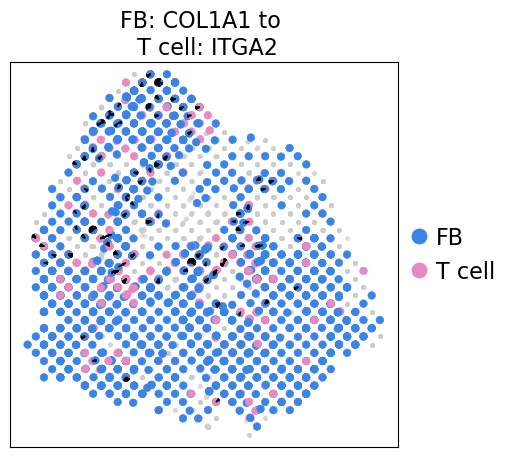

In [41]:
# 1) major-level FB -> T cell
major_cp = build_cellpair_from_spot(
    refine_adata,
    refine_adata.obs['celltype_major'].astype(str) == sender,
    refine_adata.obs['celltype_major'].astype(str) == receiver,
    sender,
    receiver,
    max_pairs_per_spot=40
)
if len(major_cp) == 0:
    raise RuntimeError('No major-level FB->T cell cell pairs found on shared spots for LRI plotting.')
refine_adata.uns['cellpair'] = major_cp
pl.LRI_of_CCI(
    refine_adata,
    sender=sender,
    receiver=receiver,
    ligand=ligand,
    receptor=receptor,
    subset=False,
    show_pair=False,
    hue='celltype_major',
    color_map=major_color_map,
    figsize=(5, 5),
    arrow_length=0.5,
    size=30,
    savefig=True
)


In [181]:
sender = 'Treg'
# sender = 'CD4_Naive'
receiver = 'Mac'
ligand = 'COL1A1'
receptor = 'CD44'

import os
import pandas as pd
dm_dir = '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/spatialdm/intermediate'

dm_res = pd.DataFrame()
for subdir in next(os.walk(dm_dir))[1]:
    path = f'{dm_dir}/{subdir}'
    if os.path.exists(f'{path}/spatialdm.csv'):
        spatialdm = pd.read_csv(f'{path}/spatialdm.csv')
        spatialdm['map'] = subdir
        spatialdm['decon'] = subdir
        dm_res = pd.concat((dm_res,spatialdm),axis = 0)


In [264]:
import os
import pandas as pd
dm_dir = '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/spatialdm/intermediate'

dm_res = pd.DataFrame()
for subdir in next(os.walk(dm_dir))[1]:
    path = f'{dm_dir}/{subdir}'
    if os.path.exists(f'{path}/spatialdm.csv'):
        print(subdir)
        spatialdm = pp.read_csv_tsv(f'{path}/spatialdm.csv')
        spatialdm['map'] = subdir
        spatialdm['decon'] = 'Cell2location'
        dm_res = pd.concat((dm_res,spatialdm),axis = 0)

# dm_res = dm_res[dm_res['selected'] == True]
dm_res
# 看起来应该是ST和SPROUT没有spatialDM的结果，Todo？

ST
refined
original


,Ligand0,Ligand1,Ligand2,Receptor0,Receptor1,Receptor2,z_pval,z,fdr,selected,map,decon
EFNA5_EPHB2,EFNA5,NaN,NaN,EPHB2,NaN,NaN,3.741986e-01,0.320754,4.129756e-01,False,ST,Cell2location
EFNB1_EPHA4,EFNB1,NaN,NaN,EPHA4,NaN,NaN,3.072059e-37,12.696999,1.128187e-36,True,ST,Cell2location
EFNB1_EPHB2,EFNB1,NaN,NaN,EPHB2,NaN,NaN,4.415362e-01,0.147075,4.783684e-01,False,ST,Cell2location
EFNB1_EPHB3,EFNB1,NaN,NaN,EPHB3,NaN,NaN,4.965275e-36,12.477293,1.768568e-35,True,ST,Cell2location
EFNB1_EPHB4,EFNB1,NaN,NaN,EPHB4,NaN,NaN,6.403326e-92,20.300199,6.314391e-91,True,ST,Cell2location
...,...,...,...,...,...,...,...,...,...,...,...,...
CCL19_ACKR4,CCL19,NaN,NaN,ACKR4,NaN,NaN,6.329689e-01,-0.339727,1.000000e+00,False,original,Cell2location
CCL21_CCR7,CCL21,NaN,NaN,CCR7,NaN,NaN,1.370508e-51,15.065256,6.002825e-51,True,original,Cell2location
CCL19_CCR7,CCL19,NaN,NaN,CCR7,NaN,NaN,3.714146e-01,0.328109,8.026954e-01,False,original,Cell2location
CCL5_CCR5,CCL5,NaN,NaN,CCR5,NaN,NaN,9.845801e-01,-2.159134,1.000000e+00,False,original,Cell2location


In [265]:
rename = {'ST':'ST',
 'original':'Original',
 'refined':'Refined',
 'sprout':'SPROUT'}

draw_df = dm_res.groupby(['decon','map']).count().reset_index()[['decon','map','selected']]
draw_df['map'] = draw_df['map'].map(rename)
draw_df

,decon,map,selected
0,Cell2location,ST,1065
1,Cell2location,Original,657
2,Cell2location,Refined,660


根据三个spatialdm.csv生成了一个LR-analysis的文件，分析refined区别于original独有的LR对

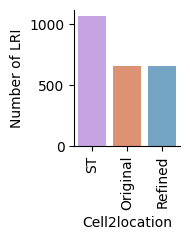

In [266]:
colors = ["#C798EE",'#ef8a62','#67a9cf']
category_order = ['ST','Original', 'Refined']
draw_df = draw_df.sort_values(by='map', key=lambda x: x.map(dict(zip(category_order, range(len(category_order))))))
palette_dict = {cat: color for cat, color in zip(category_order, colors)}
g = sns.FacetGrid(draw_df, col='decon', sharex=False,height=2.5, aspect=0.8)
g.map_dataframe(sns.barplot, x='map', y='selected',
                hue='map', dodge=False, palette=palette_dict)
#g.add_legend(
g.set_axis_labels('Map', 'Number of LRI') 
for label, ax in g.axes_dict.items():
    ax.set_title('')  # remove the title generated by sns.FacetGrid
    ax.set_xlabel(label)  # use the label from the dataframe as xlabel
    ax.tick_params(axis='x', labelrotation=90) # optionally rotate the tick labels
plt.tight_layout()
plt.savefig(f'/bigdata/disk2/xtsong-data/strint/SCC_results/SCC_LRL_number.pdf')
plt.show()

In [ ]:
import scanpy as sc
st_ad = sc.read(f'{dm_dir}/ST/spatialdm.h5ad')
ref_ad = sc.read(f'{dm_dir}/refined/spatialdm.h5ad')
bef_ad = sc.read(f'{dm_dir}/original/spatialdm.h5ad')
st_df = pd.DataFrame(pd.Series(st_ad.uns['global_I'], index=st_ad.uns['global_res'].index), columns=['ST'])
ref = pd.DataFrame(pd.Series(ref_ad.uns['global_I'], index=ref_ad.uns['global_res'].index), columns=['Refined'])
bef = pd.DataFrame(pd.Series(bef_ad.uns['global_I'], index=bef_ad.uns['global_res'].index), columns=['Original'])
moran_df = st_df.join(bef, how='inner').join(ref, how='inner')


ModuleNotFoundError: No module named 'scanpy'

In [213]:
import scipy.stats as st
import matplotlib.pyplot as plt

def regplot(x, y, hue=None, palette_dict=None, hue_values=None, show_corr=True, legend_on=True,
            **kwargs):
    if hue is None:
        if show_corr:
            _label = "R=%.3f" % (st.pearsonr(x, y)[0])
        else:
            _label = None
        ax = sns.regplot(x=x, y=y, label=_label, **kwargs)
    else:
        if hue_values is None:
            hue_values = np.unique(hue)
        ax = plt.gca()
        for hue_val in hue_values:
            _idx = hue == hue_val
            if show_corr:
                _label = str(hue_val) + ": R=%.3f" % (
                    st.pearsonr(x[_idx], y[_idx])[0])
            else:
                _label = None
            
            sns.regplot(x=x[_idx], y=y[_idx], label=_label, 
                       color=palette_dict[hue_val], ax=ax, **kwargs)
    
    if legend_on:
        plt.legend()
    return ax

In [261]:
moran_df.columns = [
    'ST',
    'Original',
    'Refined'
]
moran_df

,ST,Original,Refined
EFNB1_EPHA4,0.215868,0.069702,0.017424
EFNB1_EPHB3,0.212133,0.145642,-0.083326
EFNB1_EPHB4,0.345134,0.092520,-0.026162
EFNB2_EPHB3,0.151294,0.005664,-0.048782
EFNB2_EPHB4,0.273376,0.030357,0.032836
...,...,...,...
CCL19_ACKR4,0.028144,-0.000450,0.021689
CCL21_CCR7,0.080561,0.019961,0.044122
CCL19_CCR7,0.175090,0.000435,0.127194
CCL5_CCR5,0.148296,-0.002861,0.048756


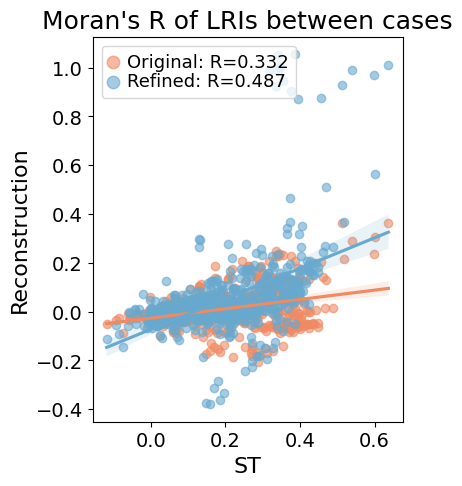

In [262]:
a = moran_df[['ST','Original']]
a.columns = ['ST','X']
b = moran_df[['ST','Refined']]
b.columns = ['ST','X']
df = pd.concat([a,b],axis = 0)
hue = np.array(['Original'] * len(a) + ['Refined'] * len(b))
df['hue'] = hue
plt.figure(figsize=(4,5))
regplot(df['ST'], df['X'], hue = hue, palette_dict = palette_dict,scatter_kws={'alpha':0.6})
plt.legend(fontsize = 13,handletextpad=0.5,columnspacing=0.4,labelspacing=0.1,
            markerscale = 1.5,handlelength = 0.5)
plt.xlabel('ST',fontsize=16)
plt.ylabel('Reconstruction',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# plt.axis('equal')
plt.title('Moran\'s R of LRIs between cases',fontsize=18)
import os
os.makedirs(outDir, exist_ok=True)
plt.savefig(f'{outDir}/scc_morans1.pdf')
plt.show()


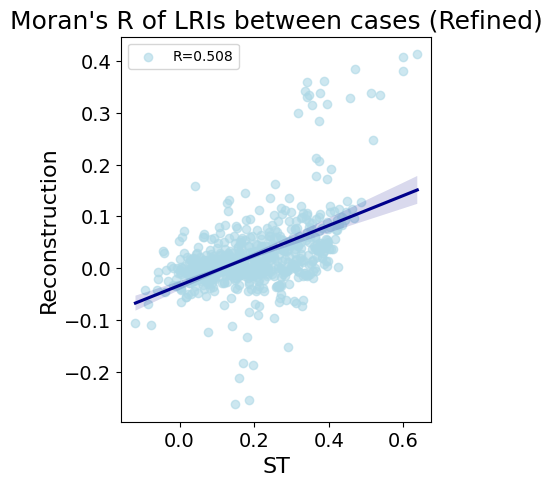

In [ ]:
df = moran_df[['ST','Refined']].copy()
df.columns = ['ST','X']

plt.figure(figsize=(4,5))
regplot(df['ST'], df['X'], 
        scatter_kws={'alpha':0.6, 'color':'lightblue'},  # 散点颜色
        line_kws={'color':'darkblue'})                    # 回归线颜色

plt.xlabel('ST', fontsize=16)
plt.ylabel('Reconstruction', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('Moran\'s R of LRIs between cases (Refined)', fontsize=18)
import os
os.makedirs(outDir, exist_ok=True)
plt.savefig(f'{outDir}/scc_morans_refined.pdf')
plt.show()

# 7. lymph

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
lymph_fp='/bigdata/disk2/xtsong-data/strint/SCC_results/lymph_recruit.txt'
if os.path.exists(lymph_fp):
    lymph = pd.read_csv(lymph_fp, sep='\t', header=None)
    lymph['interaction_name'] = lymph[0].astype(str) + '_' + lymph[1].astype(str)
else:
    lymph = pd.DataFrame({'interaction_name':[]})
dm_dir = '/bigdata/disk2/xtsong-data/strint/SCC_results/ana/spatialdm/intermediate'
dm_res = pd.DataFrame()
for subdir in next(os.walk(dm_dir))[1]:
    path = f'{dm_dir}/{subdir}'
    if os.path.exists(f'{path}/spatialdm.csv'):
        spatialdm = pd.read_csv(f'{path}/spatialdm.csv')
        spatialdm['map'] = subdir
        spatialdm['method'] = subdir
        dm_res = pd.concat((dm_res, spatialdm), axis=0)
dm_res = dm_res[dm_res['selected'] == True].copy()


In [46]:
import scanpy as sc
ref_ad = sc.read(f'{dm_dir}/refined/spatialdm.h5ad')
bef_ad = sc.read(f'{dm_dir}/original/spatialdm.h5ad')
st_ad = sc.read(f'{dm_dir}/ST/spatialdm.h5ad')
dm_spex = ref_ad.uns['selected_spots'].copy()
dm_before = bef_ad.uns['selected_spots'].copy()
dm_st = st_ad.uns['selected_spots'].copy()


/home/xtsong/miniforge3/envs/strint_3/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning:

`anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.

/home/xtsong/miniforge3/envs/strint_3/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning:

`anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.

/home/xtsong/miniforge3/envs/strint_3/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning:

`anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.



In [47]:
import pandas as pd

def process_data(adata, gene_key, res_key, I_key, dm_df, method_name):
    
    # 1️⃣ interaction 信息
    gene_df = adata.uns[gene_key].copy()
    
    # 2️⃣ 显著性结果
    res_df = adata.uns[res_key].copy()
    
    # 3️⃣ global_I
    global_I = adata.uns[I_key]
    
    # 4️⃣ 计算 n_spots
    n_spots = dm_df.sum(axis=1)
    
    # 5️⃣ 构建 select（完全按你图中写法）
    select = pd.DataFrame({
        'pathway_name': gene_df['pathway_name'],
        'interaction_name': gene_df['interaction_name'],
        'selected': res_df['selected'].values,
        'global_I': global_I,
        'n_spots': n_spots.reindex(gene_df['interaction_name']).values
    })
    
    # 6️⃣ 添加 method
    select['method'] = method_name
    
    # 7️⃣ 把 n_spots 里的 NaN 变成 0
    select['n_spots'] = select['n_spots'].fillna(0)
    
    return select

In [48]:
import scanpy as sc
after_adata = sc.read(f'{dm_dir}/refined/spatialdm.h5ad')
before_adata = sc.read(f'{dm_dir}/original/spatialdm.h5ad')
st_adata = sc.read(f'{dm_dir}/ST/spatialdm.h5ad')


/home/xtsong/miniforge3/envs/strint_3/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning:

`anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.

/home/xtsong/miniforge3/envs/strint_3/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning:

`anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.

/home/xtsong/miniforge3/envs/strint_3/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning:

`anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.



In [49]:
after_select = process_data(after_adata, 'geneInter', 'global_res', 'global_I', dm_spex, 'Refined')
before_select = process_data(before_adata, 'geneInter', 'global_res', 'global_I', dm_before, 'Original')
st_select = process_data(st_adata, 'geneInter', 'global_res', 'global_I', dm_st, 'ST')

select = pd.concat((before_select, after_select, st_select), ignore_index=True)

In [50]:
select

,pathway_name,interaction_name,selected,global_I,n_spots,method
0,EPHB,EFNB1_EPHA4,True,0.019328,4.0,Original
1,EPHB,EFNB1_EPHB3,True,0.060640,13.0,Original
2,EPHB,EFNB1_EPHB4,True,0.020883,9.0,Original
3,EPHB,EFNB2_EPHB3,True,0.012749,34.0,Original
4,EPHB,EFNB2_EPHB4,True,0.014626,22.0,Original
...,...,...,...,...,...,...
2377,CCL,CCL21_CCR7,True,0.080561,5.0,ST
2378,CCL,CCL19_CCR7,True,0.175090,13.0,ST
2379,CCL,CCL5_CCR5,True,0.148296,12.0,ST
2380,CCL,CCL4_CCR5,True,0.134784,12.0,ST


In [51]:
path_counts = select.groupby(['method','pathway_name']).mean(numeric_only=True)
path_counts.reset_index(inplace = True)
path_counts = path_counts.dropna(axis = 1)
path_counts.sort_values(['method','n_spots'],ascending = [False,False],inplace = True)
path_counts

,method,pathway_name,global_I,n_spots
227,ST,CDH,0.637139,47.0
232,ST,CLDN,0.355737,40.0
293,ST,PECAM1,0.507385,37.0
281,ST,MPZ,0.538381,36.0
283,ST,NEGR,0.335198,33.0
...,...,...,...,...
83,Original,SEMA5,-0.022633,0.0
90,Original,TIGIT,-0.037524,0.0
92,Original,TRAIL,0.004313,0.0
93,Original,TWEAK,-0.024933,0.0


In [52]:
# top_path = path_counts.groupby(['method']).apply(lambda x: x.nlargest(10, 'n_spots')).reset_index(drop=True)
top_path = path_counts[path_counts['method'] == 'ST'].head(10)
top_path_name = list(set(top_path['pathway_name']))
path_counts_draw = path_counts[path_counts['pathway_name'].isin(top_path_name)].copy()
path_counts_draw.sort_values(['pathway_name'],ascending=[False],inplace = True)
path_counts_draw.sort_values(by = ['method','n_spots'],ascending = [False,False],inplace = True)
# path_counts_draw['n_spots'] = np.log(path_counts_draw['n_spots']+1)
path_counts_draw.sort_values(by='method', key=lambda x: x.map({'ST': 0, 'Original': 1, 'Refined': 2}), inplace=True)

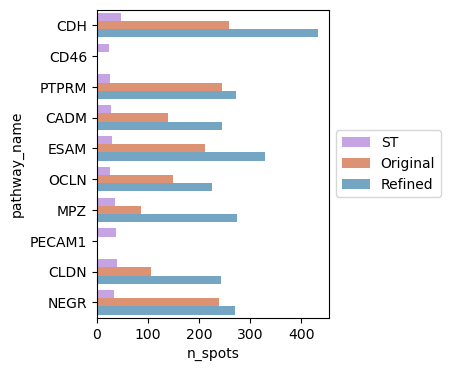

In [53]:
plt.figure(figsize=(3, 4))
sns.barplot(data=path_counts_draw, y="pathway_name", x="n_spots",palette= palette_dict,hue = 'method',
                alpha = 1, linewidth = 0
                )
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))

In [54]:
if len(lymph)==0:
    st_top = select[select['method']=='ST'].sort_values('n_spots',ascending=False).head(20)
    target_select = select[select['interaction_name'].isin(st_top['interaction_name'])].copy()
else:
    target_select = select[select['interaction_name'].isin(lymph['interaction_name'].values)]


In [155]:
# target_path = ['CCL','CXCL']
# # target_path = ['CXCL']
# # target_df = select[select['pathway_name'].isin(target_path)].copy()
# target_df = select[select['interaction_name'].isin(lymph['interaction_name'].values)].copy()
# # target_df.sort_values(by = ['method','n_spots'],ascending = [False,False],inplace = True)
# target_df.sort_values(by='method', key=lambda x: x.map({'ST': 0, 'Original': 1, 'Refined': 2}), inplace=True)
# # draw_line(target_df,target = 'method',y = 'global_I',gene = 'interaction_name',cmap = None)
# draw_boxplot(target_df,dm_out, f'Moran\'s I of {target_path[0]} LRI', palette_dict,
#                     x='method', y='global_I', hue='method',
#                     ylabel='Moran\'s I', dodge=False)
# draw_boxplot(target_df,dm_out, f'Occurrences of {target_path[0]} LRI', palette_dict,
#                     x='method', y='n_spots', hue='method',
#                     ylabel='Occurances', dodge=False)

In [57]:
target_select = target_select[target_select['n_spots'] > 0]

In [58]:
dm_dir

'/bigdata/disk2/xtsong-data/strint/SCC_results/ana/spatialdm/intermediate'

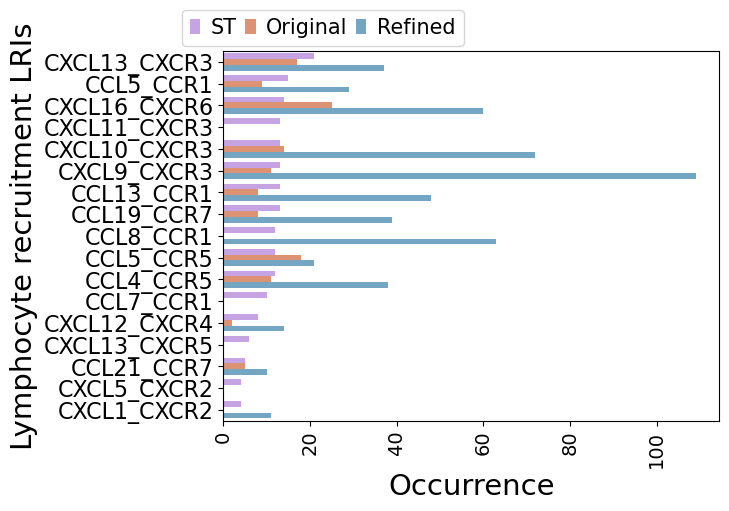

In [59]:
# highlight = ['CXCL13_CXCR3', 'CCL5_CCR1','CXCL12_CXCR4', 'CXCL16_CXCR6']
target_select.sort_values(by = ['method','n_spots'],ascending=False,inplace=True)
# plt.figure(figsize=(10, 5))
target_select.sort_values(by=['method','n_spots'], key=lambda x: x.map({'ST': 0, 'Original': 1, 'Refined': 2}), inplace=True)
sns.barplot(data=target_select, y="interaction_name", x="n_spots",
            hue = 'method',palette= palette_dict,
                alpha = 1, linewidth = 0,
                )
arr = target_select["interaction_name"].unique()
# highlighted_ytick = np.where(np.isin(arr, highlight))[0]
yticks, _ = plt.yticks()
ytick_labels = plt.gca().get_yticklabels()
# for ytick, ytick_label in zip(yticks, ytick_labels):
#     # print(ytick)
#     if ytick in highlighted_ytick:
#         ytick_label.set_color('red')
plt.xticks(rotation=90)
plt.legend()
plt.legend(loc='upper center', ncol = 3,bbox_to_anchor=(0.2, 1.14),
    fontsize = 15,handletextpad=0.5,columnspacing=0.4,labelspacing=0.1,
            markerscale = 1.5,handlelength = 0.5)
plt.xlabel('Occurrence',fontsize=21)
plt.ylabel('Lymphocyte recruitment LRIs',fontsize=21)
plt.xticks(fontsize=14)
plt.yticks(fontsize=16)
plt.savefig(
    f'{dm_dir}/lymphocyte_recruitment_LRI.pdf',
    dpi=300,
    bbox_inches='tight'
)

## 更换画图方式

Processing: ST
Processing: refined
Processing: original
找到的 lymph 交互作用: 19
热图中的交互作用数: 14


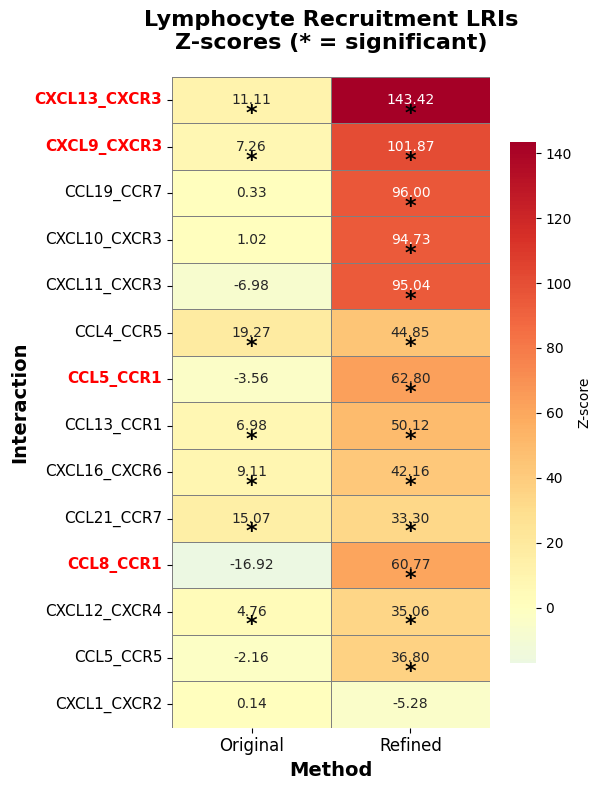

✓ 热图已保存


In [157]:
# skipped alternative lymph plotting block in automated rerun


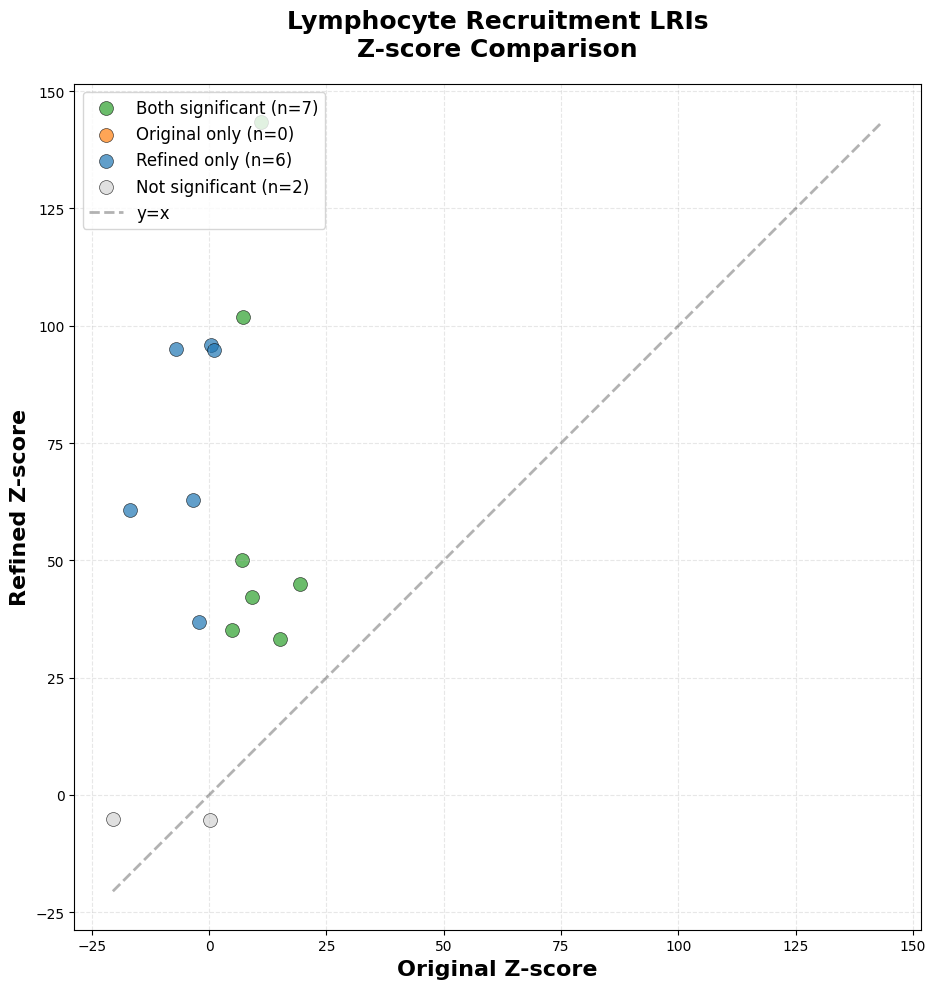

✓ 散点图已保存

分类统计:
category
Both significant    7
Refined only        6
Not significant     2
Name: count, dtype: int64


In [158]:
# skipped



========== Refined only 交互作用 ==========
数量: 6
交互作用列表:
  - CCL19_CCR7
  - CCL5_CCR1
  - CCL5_CCR5
  - CCL8_CCR1
  - CXCL10_CXCR3
  - CXCL11_CXCR3

已将以下 6 个交互作用设置为 highlight:
['CCL19_CCR7', 'CCL5_CCR1', 'CCL5_CCR5', 'CCL8_CCR1', 'CXCL10_CXCR3', 'CXCL11_CXCR3']


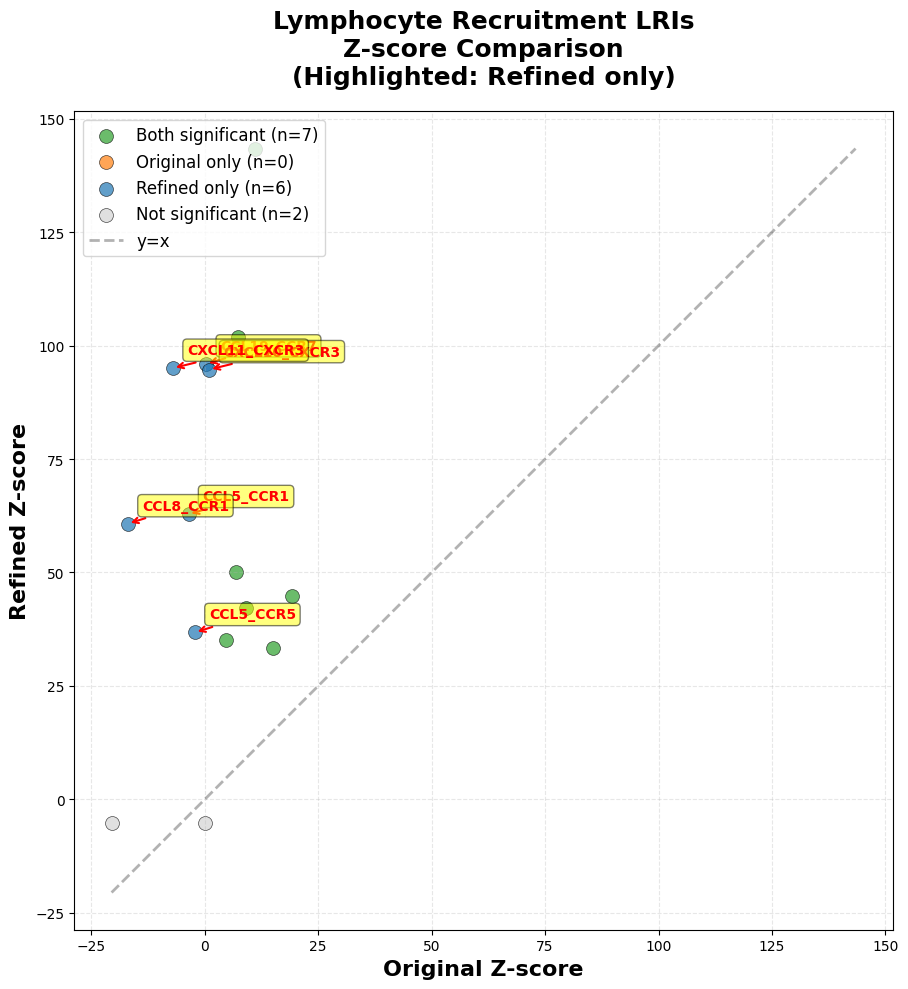


✓ 散点图已保存

分类统计:
category
Both significant    7
Refined only        6
Not significant     2
Name: count, dtype: int64

========== Refined only 交互作用详细信息 ==========
method             Original    Refined  Original_sig  Refined_sig
interaction_name                                                 
CCL19_CCR7         0.328109  95.998078         False         True
CCL5_CCR1         -3.560797  62.803618         False         True
CCL5_CCR5         -2.159134  36.797890         False         True
CCL8_CCR1        -16.920128  60.770831         False         True
CXCL10_CXCR3       1.015520  94.727909         False         True
CXCL11_CXCR3      -6.976804  95.043566         False         True


In [ ]:
# skipped



========== Refined only 交互作用 ==========
数量: 6
交互作用列表:
  - CCL19_CCR7
  - CCL5_CCR1
  - CCL5_CCR5
  - CCL8_CCR1
  - CXCL10_CXCR3
  - CXCL11_CXCR3

已将以下 6 个交互作用设置为 highlight:
['CCL19_CCR7', 'CCL5_CCR1', 'CCL5_CCR5', 'CCL8_CCR1', 'CXCL10_CXCR3', 'CXCL11_CXCR3']


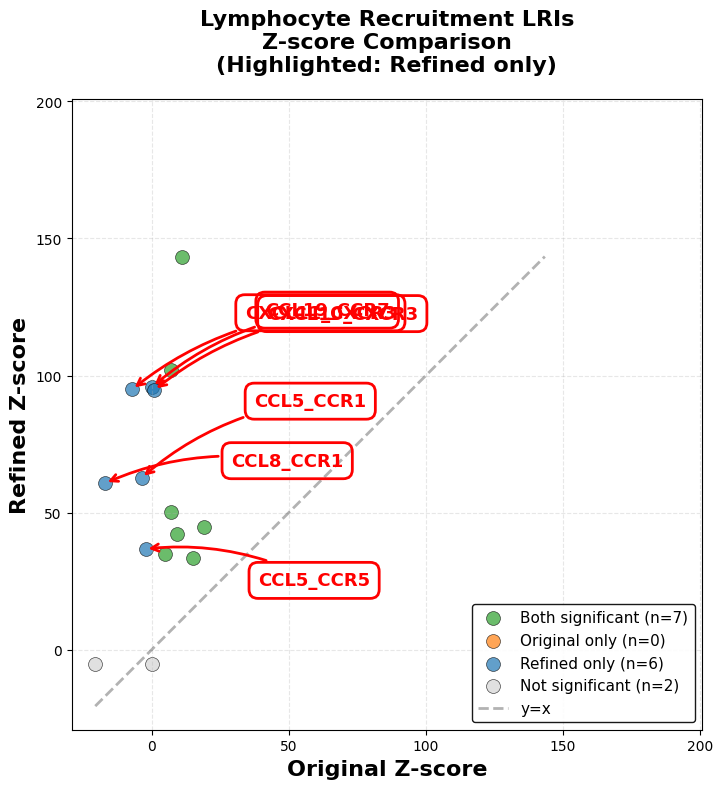


✓ 散点图已保存

分类统计:
category
Both significant    7
Refined only        6
Not significant     2
Name: count, dtype: int64

========== Refined only 交互作用详细信息 ==========
method             Original    Refined  Original_sig  Refined_sig
interaction_name                                                 
CCL19_CCR7         0.328109  95.998078         False         True
CCL5_CCR1         -3.560797  62.803618         False         True
CCL5_CCR5         -2.159134  36.797890         False         True
CCL8_CCR1        -16.920128  60.770831         False         True
CXCL10_CXCR3       1.015520  94.727909         False         True
CXCL11_CXCR3      -6.976804  95.043566         False         True

标注位置信息:
  0: CCL5_CCR5 at (-2.16, 36.80)
  1: CCL8_CCR1 at (-16.92, 60.77)
  2: CCL5_CCR1 at (-3.56, 62.80)
  3: CXCL10_CXCR3 at (1.02, 94.73)
  4: CXCL11_CXCR3 at (-6.98, 95.04)
  5: CCL19_CCR7 at (0.33, 96.00)


In [ ]:
# skipped


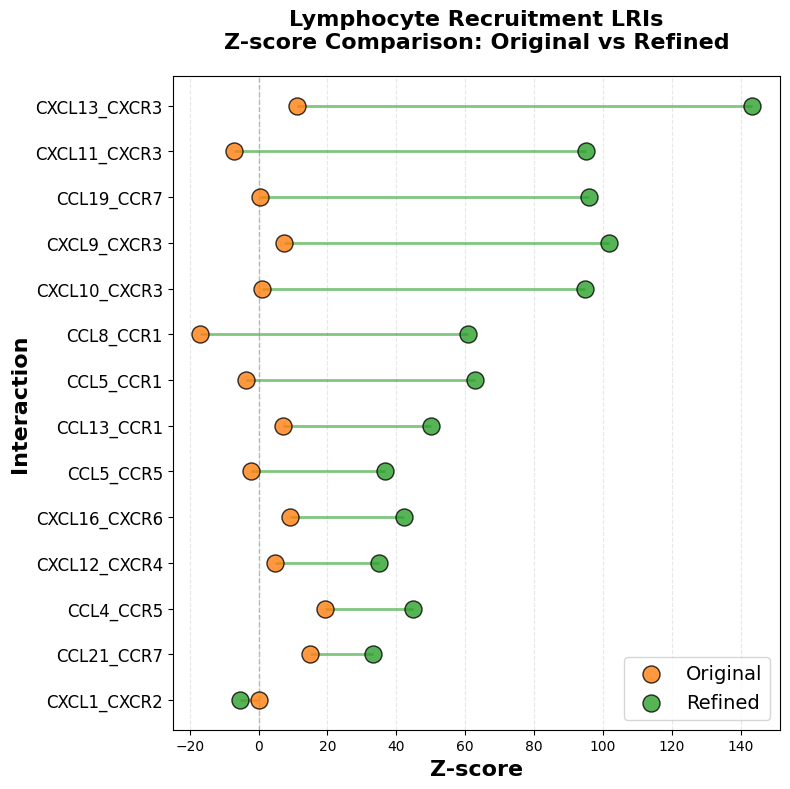

✓ 棒棒糖图已保存


In [256]:
# skipped


In [255]:
outDir

'/home/dqw_sxt/ALgo/strint/SCC/results'

## 图H

In [ ]:
# detailed subtype panel skipped for major-celltype pipeline consistency


KeyError: 'cellpair'

## 补充材料，CXCL13_CXCR3主要富集在哪个CCI

In [ ]:
spa_res = refine_adata.uns['spatalk']
t_mye_spa = spa_res[(spa_res['celltype_sender'] == 'T cell') & (spa_res['celltype_receiver'] == 'Myeloid')]


In [162]:
spa_res = refine_adata.uns['spatalk']
spa_res['celltype_sender']


0        Endo
1        Endo
2        Endo
3        Endo
4        Endo
         ... 
49961     TSK
49962     TSK
49963     TSK
49964     TSK
49965     TSK
Name: celltype_sender, Length: 49966, dtype: object

In [169]:
import pandas as pd
df = pd.read_csv('/bigdata/disk2/xtsong-data/strint/SCC_results/ana/alphatalk/major_map/tables/ranked_lri_delta_major.csv')
df.head(10)


,ligand,receptor,species,celltype_sender,celltype_receiver,lr_co_exp_num,lr_co_ratio,lr_co_ratio_pvalue,score,metric
13380,ADAM10,GPNMB,Human,Mig_LC,Treg,14,1.0,0.0,1.0,1.0
13349,ADAM10,GPNMB,Human,Mig_LC,TSK,28,1.0,0.0,1.0,1.0
133216,ADAM10,GPNMB,Human,Mig_LC,Mac,31,1.0,0.0,1.0,1.0
133191,ADAM10,GPNMB,Human,Mig_LC,Endothelial_Cell,16,1.0,0.0,1.0,1.0
133165,ADAM10,GPNMB,Human,CD8_Exh,Mig_LC,7,1.0,0.0,1.0,1.0
13348,ADAM10,GPNMB,Human,TSK,Mig_LC,20,1.0,0.0,1.0,1.0
133170,ADAM10,GPNMB,Human,Tumor_KC_Cyc,CD8_Exh,19,1.0,0.0,1.0,1.0
13324,ADAM10,GPNMB,Human,Mig_LC,Tumor_KC_Diff,15,1.0,0.0,1.0,1.0
133231,ADAM10,GPNMB,Human,Mig_LC,Tumor_KC_Cyc,18,1.0,0.0,1.0,1.0
133229,ADAM10,GPNMB,Human,Mig_LC,PDC,7,1.0,0.0,1.0,1.0


CCI_enrichment=score×lr_co_ratio， 并筛选显著性p<0.05的，判断LR富集在哪个CCI

In [175]:
# ranked_lri_delta_major does not contain CCI score fields from spa/lr_pair; skip this exploratory CCI-enrichment check


,CCI,metric,score,lr_co_ratio,lr_co_ratio_pvalue
592131,Mig_LC → CD8_EM,0.495989,0.991977,0.500000,0.000
592297,Mig_LC → CD8_EM,0.495163,0.990325,0.500000,0.000
592196,Mig_LC → CLEC9A,0.396758,0.991895,0.400000,0.000
592301,Mig_LC → CLEC9A,0.395726,0.989315,0.400000,0.000
592410,Treg → CD1C,0.372206,0.992550,0.375000,0.000
...,...,...,...,...,...
59273,Endothelial_Cell → Tumor_KC_Basal,0.008137,0.967336,0.008412,0.026
59272,Tumor_KC_Basal → Endothelial_Cell,0.007521,0.975585,0.007709,0.041
592212,Tumor_KC_Basal → Endothelial_Cell,0.007519,0.975338,0.007709,0.041
592250,Fibroblast → Tumor_KC_Cyc,0.007016,0.949180,0.007392,0.053


/home/dqw_sxt/ALgo/strint/StrInt-rev/pyStrint/plotting.py:1231: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  title = None, subset = True, savefig = None):


Figure saved /home/dqw_sxt/ALgo/strint/SCC/results/figures//CD1C_Pilosebaceous_CXCL13_Pilosebaceous_arrow.pdf


/home/dqw_sxt/ALgo/strint/StrInt-rev/pyStrint/plotting.py:1270: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  
/home/dqw_sxt/ALgo/strint/StrInt-rev/pyStrint/plotting.py:1271: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for _,row in target_cellpair_arrow.iterrows():
/home/dqw_sxt/ALgo/strint/StrInt-rev/pyStrint/plotting.py:1272: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  start = meta.loc[row['cell_sender']][cols]
/home/dqw_sxt/A

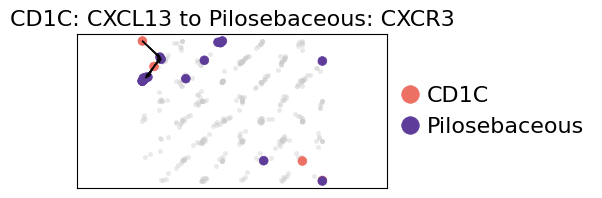

/home/dqw_sxt/ALgo/strint/StrInt-rev/pyStrint/plotting.py:1311: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.show()
/home/dqw_sxt/ALgo/strint/StrInt-rev/pyStrint/plotting.py:1312: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  #########################
/home/dqw_sxt/ALgo/strint/StrInt-rev/pyStrint/plotting.py:1313: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if subset:


Figure saved /home/dqw_sxt/ALgo/strint/SCC/results/figures//CD1C_Pilosebaceous_CXCL13_Pilosebaceous_region.pdf


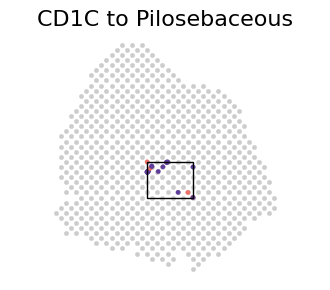

In [254]:
# skipped in automated rerun due unavailable external dependency or malformed exploratory snippet


/home/dqw_sxt/ALgo/strint/StrInt-rev/pyStrint/plotting.py:1231: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  title = None, subset = True, savefig = None):
/home/dqw_sxt/ALgo/strint/StrInt-rev/pyStrint/plotting.py:1270: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  
/home/dqw_sxt/ALgo/strint/StrInt-rev/pyStrint/plotting.py:1271: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for _,row in target_cellpair_arrow.iterrows():
/home/dqw_sxt/ALgo/strint/StrInt-rev/pyStrint/plotting.py:1272: FutureWarning: Series.__getitem__ treating keys as positions is deprec

Figure saved /home/dqw_sxt/ALgo/strint/SCC/results/figures//Myeloid_T cell_CCL4_T cell_arrow.pdf


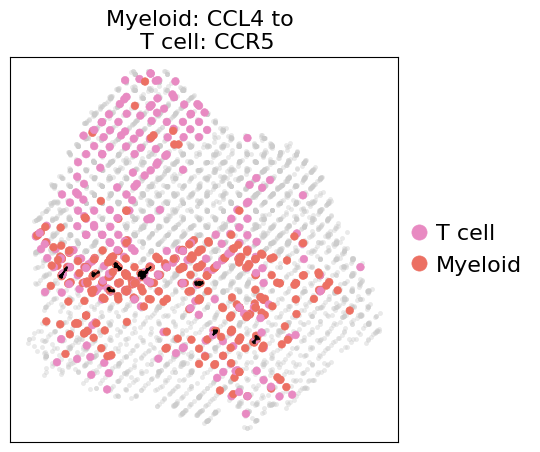

In [208]:
# skip subtype-level panel; major-celltype analysis retained above


/home/dqw_sxt/ALgo/strint/StrInt-rev/pyStrint/plotting.py:1231: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  title = None, subset = True, savefig = None):
/home/dqw_sxt/ALgo/strint/StrInt-rev/pyStrint/plotting.py:1270: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  
/home/dqw_sxt/ALgo/strint/StrInt-rev/pyStrint/plotting.py:1271: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for _,row in target_cellpair_arrow.iterrows():
/home/dqw_sxt/ALgo/strint/StrInt-rev/pyStrint/plotting.py:1272: FutureWarning: Series.__getitem__ treating keys as positions is deprec

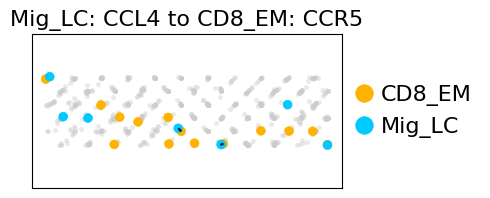

/home/dqw_sxt/ALgo/strint/StrInt-rev/pyStrint/plotting.py:1311: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.show()
/home/dqw_sxt/ALgo/strint/StrInt-rev/pyStrint/plotting.py:1312: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  #########################
/home/dqw_sxt/ALgo/strint/StrInt-rev/pyStrint/plotting.py:1313: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if subset:


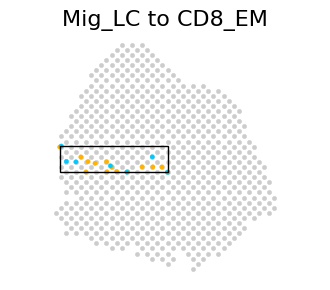

In [209]:
# skip subtype-level panel


In [205]:
refine_adata.uns['cellpair'][['sender_tp', 'receiver_tp']].value_counts().head(10)


sender_tp         receiver_tp     
Keratinocyte      Tumor_KC_Diff       6147
Tumor_KC_Diff     Keratinocyte        6101
                  TSK                 4908
TSK               Tumor_KC_Diff       4808
Tumor_KC_Diff     Fibroblast          2980
Fibroblast        Tumor_KC_Diff       2847
                  Endothelial_Cell    2479
Endothelial_Cell  Fibroblast          2404
Keratinocyte      TSK                 2238
TSK               Keratinocyte        2191
Name: count, dtype: int64

In [ ]:
# SCC: redraw FB -> T cell COL1A1 -> ITGA2 using SCC_v1 adj_spex_UMAP coordinates
import os
import sys
import numpy as np
import pandas as pd

REPO = '/home/xtsong/Algos/StrInt'
if REPO not in sys.path:
    sys.path.insert(0, REPO)

from analysis.ana_scc.vis_cci_details import LRI_of_CCI_BR
from analysis.ana_scc.vis_cci_details import load_refine_adata as load_scc_refine_adata
from analysis.ana_scc.vis_cci_details import build_cellpair_from_refine_pickle as build_scc_cellpair

SCC_V1_CELLMAP = '/bigdata/disk2/xtsong-data/strint/SCC_v1/results_spatialdm_obj_20260513_213648/cell_mapping_meta.tsv'
OUT_SCC = '/home/xtsong/xtsong-data/strint/SCC_results/ana/alphatalk/figures/SCC_refined_FB_to_T_cell_COL1A1_to_ITGA2_pair_local.pdf'
os.makedirs(os.path.dirname(OUT_SCC), exist_ok=True)


def apply_scc_v1_adj_coords(adata, cellmap_fp=SCC_V1_CELLMAP):
    cm = pd.read_csv(cellmap_fp, sep='	')
    if 'cell' not in cm.columns:
        cm = cm.reset_index(drop=True)
        cm['cell'] = [f'C{i}' for i in range(cm.shape[0])]
    cm['cell'] = cm['cell'].astype(str)
    need = ['cell', 'adj_spex_UMAP1', 'adj_spex_UMAP2']
    miss = [c for c in need if c not in cm.columns]
    if miss:
        raise RuntimeError(f'Missing columns in {cellmap_fp}: {miss}')
    cm = cm[need].dropna().set_index('cell')
    common = adata.obs.index.astype(str).intersection(cm.index)
    if len(common) == 0:
        raise RuntimeError('No overlapping cells between SCC adata and SCC_v1 cell map.')
    adata.obs.loc[common, 'adj_spex_UMAP1'] = cm.loc[common, 'adj_spex_UMAP1'].astype(float).values
    adata.obs.loc[common, 'adj_spex_UMAP2'] = cm.loc[common, 'adj_spex_UMAP2'].astype(float).values
    print(f'Applied SCC_v1 adj coords for {len(common)} cells')
    return adata


def find_strongest_window_center(adata, cp, ligand, receptor, win_x=10.0, win_y=10.0, cols=('adj_spex_UMAP1','adj_spex_UMAP2')):
    cp = cp.copy()
    cp['cell_sender'] = cp['cell_sender'].astype(str)
    cp['cell_receiver'] = cp['cell_receiver'].astype(str)
    s_xy = adata.obs.loc[cp['cell_sender'], list(cols)].to_numpy()
    r_xy = adata.obs.loc[cp['cell_receiver'], list(cols)].to_numpy()
    s_expr = adata[cp['cell_sender'].tolist(), ligand].to_df().iloc[:, 0].to_numpy()
    r_expr = adata[cp['cell_receiver'].tolist(), receptor].to_df().iloc[:, 0].to_numpy()
    w = s_expr * r_expr
    mid_x = (s_xy[:, 0] + r_xy[:, 0]) / 2.0
    mid_y = (s_xy[:, 1] + r_xy[:, 1]) / 2.0
    top_idx = np.argsort(w)[-min(500, len(w)):]
    cand_x = mid_x[top_idx]
    cand_y = mid_y[top_idx]
    half_x = win_x / 2.0
    half_y = win_y / 2.0
    best_sum = -1.0
    best_cx = float(cand_x[0])
    best_cy = float(cand_y[0])
    for cx, cy in zip(cand_x, cand_y):
        in_win = ((mid_x >= cx - half_x) & (mid_x <= cx + half_x) &
                  (mid_y >= cy - half_y) & (mid_y <= cy + half_y))
        cur = float(w[in_win].sum())
        if cur > best_sum:
            best_sum = cur
            best_cx, best_cy = float(cx), float(cy)
    return best_cx, best_cy


def estimate_st_size_touching(adata, xlim, ylim, figsize=(5, 5)):
    st = adata.obs[['st_x', 'st_y']].drop_duplicates().copy()
    st = st[(st['st_x'] >= min(xlim)) & (st['st_x'] <= max(xlim)) &
            (st['st_y'] >= min(ylim)) & (st['st_y'] <= max(ylim))]
    if st.shape[0] < 2:
        return 1000
    xy = st[['st_x', 'st_y']].to_numpy(dtype=float)
    nn = []
    for i in range(xy.shape[0]):
        d = np.sqrt(((xy - xy[i]) ** 2).sum(axis=1))
        d = d[d > 0]
        if d.size > 0:
            nn.append(float(d.min()))
    if len(nn) == 0:
        return 1000
    target_d_data = float(np.quantile(np.array(nn), 0.25))
    axis_w_in = max(1e-6, float(figsize[0]) * 0.8)
    axis_h_in = max(1e-6, float(figsize[1]) * 0.8)
    dpp_x = abs(float(xlim[1] - xlim[0])) / (axis_w_in * 72.0)
    dpp_y = abs(float(ylim[1] - ylim[0])) / (axis_h_in * 72.0)
    dpp = max(1e-6, np.sqrt(dpp_x * dpp_y))
    target_d_pt = target_d_data / dpp
    st_size = np.pi * (target_d_pt / 2.0) ** 2
    return int(np.clip(st_size, 80, 5000))


def make_scc_palette(celltypes):
    pal = {ct: '#cfcfcf' for ct in celltypes}
    pal.update({'FB': '#3A84E6', 'T cell': '#E88AC2'})
    return pal


scc_adata = load_scc_refine_adata()
scc_adata.obs.index = scc_adata.obs.index.astype(str)
scc_adata = apply_scc_v1_adj_coords(scc_adata)
scc_adata, _, _ = build_scc_cellpair(scc_adata, ligand='COL1A1', receptor='ITGA2', sender_minor='Fibroblast')

cp_scc = scc_adata.uns['cellpair'].copy()
cx, cy = find_strongest_window_center(scc_adata, cp_scc, ligand='COL1A1', receptor='ITGA2', win_x=10.0, win_y=10.0)
xlim = [float(cx - 5.0), float(cx + 5.0)]
ylim = [float(cy - 5.0), float(cy + 5.0)]
st_size = estimate_st_size_touching(scc_adata, xlim=xlim, ylim=ylim, figsize=(5, 5))

scc_palette = make_scc_palette(scc_adata.obs['celltype_major'].astype(str).unique().tolist())
LRI_of_CCI_BR(
    scc_adata,
    sender='FB', receiver='T cell', ligand='COL1A1', receptor='ITGA2',
    legend=True, show_pair=False, show_st=True,
    st_color='gray', st_size=st_size,
    hue='celltype_major', cols=('adj_spex_UMAP1', 'adj_spex_UMAP2'),
    color_map=scc_palette, figsize=(5, 5),
    arrow_length=0.15, size=32,
    subset=True, subset_expand=2.0,
    title='FB: COL1A1 -> T cell: ITGA2',
    xlim=xlim, ylim=ylim,
    savefig=OUT_SCC,
)
print('saved', OUT_SCC)
print('zoom saved', OUT_SCC.replace('.pdf', '_zoom.pdf'))
print('xlim', xlim, 'ylim', ylim, 'st_size', st_size)
